In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("/Users/alvar/OneDrive/Escritorio/PROYECTOS/Python-Jupyter/GraficasTeletubbies/Cacotas_excel.xlsx", index_col=0)
df.columns = pd.to_datetime(df.columns).strftime("%b-%y")
print(df)

         Sep-24  Oct-24  Nov-24  Dec-24  Jan-25  Feb-25  Mar-25  Apr-25  \
SOFIA        32      32      30      28      31      27      36      33   
OLI          33      45      44      51      62      51      55      45   
MARIO        57      67      53      52      59      48      68      56   
ANNA         25      22      25      23      22      20      21      22   
LUCIA        50      40      44      42      52      39      63      48   
ALVARO       37      34      32      38      40      33      39      26   
NATALIA       0       0       0       0       0       0       0       0   

         May-25  Jun-25  ...  Oct-25  Nov-25  Dec-25  Jan-26  Feb-26  Mar-26  \
SOFIA        30      41  ...      31      34      35      32      34      38   
OLI          51      42  ...      50       0       0       0      31      48   
MARIO        56      57  ...      50      37      43      50      43      53   
ANNA         28      22  ...      24      25      24      21      27      32   

In [2]:
def replace_zeros_with_mean(df):
    for i in df.index:
        df_new = df.loc[i, df.columns[1:]]      # Excluye la columna de nombres
        df_new = df_new.replace(0, pd.NA)
        df_new = df_new.fillna(df_new.mean()).round().astype(int)
        df.loc[i, df.columns[1:]] = df_new

    return df


df = replace_zeros_with_mean(df)
df = df.drop("NATALIA")

C:\Users\alvar\AppData\Local\Temp\ipykernel_27904\694373934.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_new = df_new.fillna(df_new.mean()).round().astype(int)
C:\Users\alvar\AppData\Local\Temp\ipykernel_27904\694373934.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_new = df_new.fillna(df_new.mean()).round().astype(int)
C:\Users\alvar\AppData\Local\Temp\ipykernel_27904\694373934.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(cop

In [3]:
print(df)

        Sep-24  Oct-24  Nov-24  Dec-24  Jan-25  Feb-25  Mar-25  Apr-25  \
SOFIA       32      32      30      28      31      27      36      33   
OLI         33      45      44      51      62      51      55      45   
MARIO       57      67      53      52      59      48      68      56   
ANNA        25      22      25      23      22      20      21      22   
LUCIA       50      40      44      42      52      39      63      48   
ALVARO      37      34      32      38      40      33      39      26   

        May-25  Jun-25  ...  Oct-25  Nov-25  Dec-25  Jan-26  Feb-26  Mar-26  \
SOFIA       30      41  ...      31      34      35      32      34      38   
OLI         51      42  ...      50      47      47      47      31      48   
MARIO       56      57  ...      50      37      43      50      43      53   
ANNA        28      22  ...      24      25      24      21      27      32   
LUCIA       66      53  ...      54      53      46      45      44      46   
ALVARO 

In [4]:
df["Media"] = df.mean(axis=1).round(1)
df["Desviacion"] = df.std(axis=1).round(1)

In [5]:
n_meses = len(df.columns) - 2
primer_mes = df.columns[0]
ultimo_mes = df.columns[-3]  # -3 para saltar media y std

media_global = df.drop(columns=["Media", "Desviacion"]).values.mean()
std_global = df.drop(columns=["Media", "Desviacion"]).values.std()

print(media_global)
print(std_global)

39.666666666666664
11.69995251652283


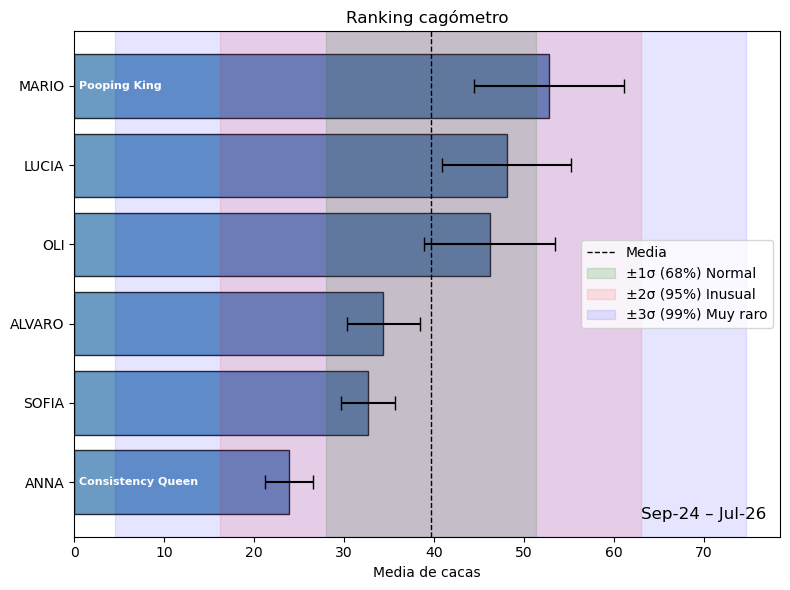

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

df_sort = df.sort_values("Media")

ax.barh(df_sort.index, df_sort["Media"], xerr=df_sort["Desviacion"], capsize=5, color="steelblue",edgecolor="black", alpha=0.8)

ax.axvline(
    x=media_global,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Media"
)

ax.set_xlabel("Media de cacas")
ax.set_title("Ranking cagómetro")

ax.text(0.98, 0.03, f"{primer_mes} – {ultimo_mes}", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=12, color="black")

# Rey de las cagadas - mayor media
rey = df_sort["Media"].idxmax()
ax.text(0.5, df_sort.index.get_loc(rey), "Pooping King",
        va="center", ha="left", fontsize=8, color="white", fontweight="bold")

# Reina de la consistencia - std más baja
reina = df_sort["Desviacion"].idxmin()
ax.text(0.5, df_sort.index.get_loc(reina), "Consistency Queen",
        va="center", ha="left", fontsize=8, color="white",fontweight="bold")

ax.axvspan(media_global - std_global, media_global + std_global, 
           alpha=0.15, color="green", label="±1σ (68%) Normal")

# Zona ±2σ
ax.axvspan(media_global - 2*std_global, media_global + 2*std_global, 
           alpha=0.1, color="red", label="±2σ (95%) Inusual")

ax.axvspan(media_global - 3*std_global, media_global + 3*std_global, 
           alpha=0.1, color="blue", label="±3σ (99%) Muy raro")

ax.legend()

plt.tight_layout()
plt.show()

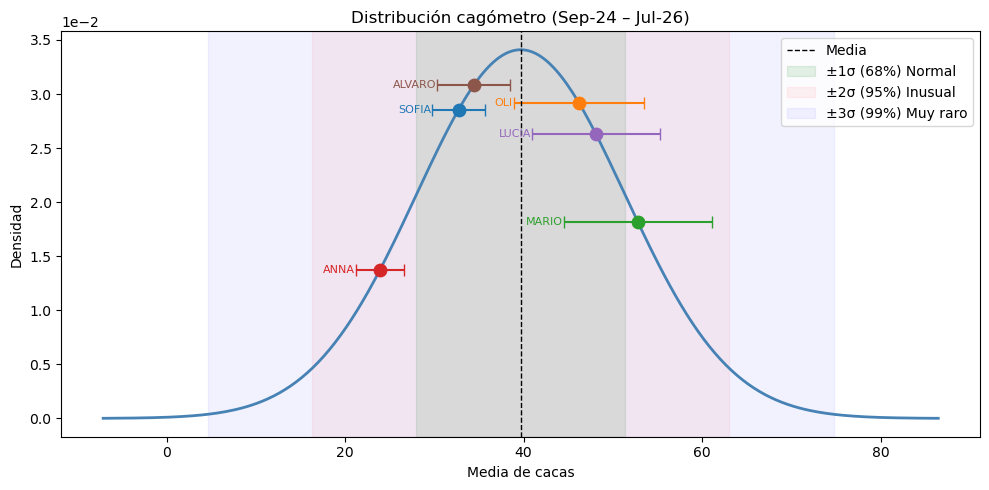

In [7]:
import numpy as np
from scipy.stats import norm

fig, ax = plt.subplots(figsize=(10, 5))

# Gaussiana global
x = np.linspace(media_global - 4*std_global, media_global + 4*std_global, 300)
ax.plot(x, norm.pdf(x, media_global, std_global), color="steelblue", linewidth=2)

# Cada persona
colors = plt.cm.tab10.colors
for i, nombre in enumerate(df.index):
    media_p = df.loc[nombre, "Media"]
    std_p = df.loc[nombre, "Desviacion"]
    y_pos = norm.pdf(media_p, media_global, std_global)
    
    # Punto
    ax.scatter(media_p, y_pos, color=colors[i], zorder=5, s=80)
    
    # Barra de error horizontal (std propia)
    ax.errorbar(media_p, y_pos, xerr=std_p, fmt="none", color=colors[i], capsize=4)
    
    # Nombre
    ax.text(media_p - std_p - 0.1, y_pos, nombre, va="center", ha="right", fontsize=8, color=colors[i])

ax.set_xlabel("Media de cacas")
ax.set_ylabel("Densidad")
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax.set_title(f"Distribución cagómetro ({primer_mes} – {ultimo_mes})")

ax.axvline(
    x=media_global,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Media"
)

ax.axvspan(media_global - std_global, media_global + std_global, 
           alpha=0.1, color="green", label="±1σ (68%) Normal")

# Zona ±2σ
ax.axvspan(media_global - 2*std_global, media_global + 2*std_global, 
           alpha=0.05, color="red", label="±2σ (95%) Inusual")

ax.axvspan(media_global - 3*std_global, media_global + 3*std_global, 
           alpha=0.05, color="blue", label="±3σ (99%) Muy raro")

ax.legend()

plt.tight_layout()
plt.show()

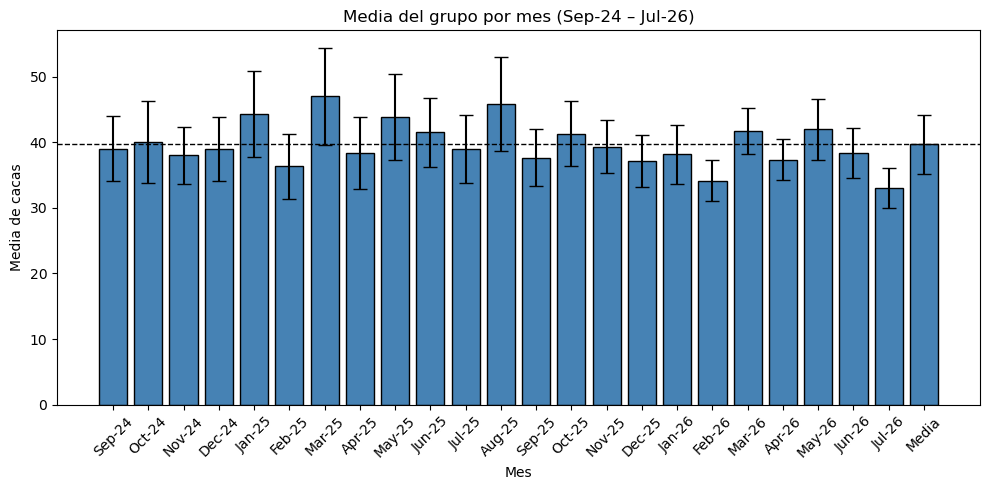

In [8]:
cols_meses = [col for col in df.columns if col not in ["Desviacion"]]
media_por_mes = df[cols_meses].mean(axis=0)

n = len(df.index)
error_por_mes = df[cols_meses].std(axis=0) / np.sqrt(n)

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(media_por_mes.index, media_por_mes.values, yerr=error_por_mes,
       capsize=5, color="steelblue", edgecolor="black")

ax.axhline(
    y=media_global,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Media"
)

ax.set_xlabel("Mes")
ax.set_ylabel("Media de cacas")
ax.set_title(f"Media del grupo por mes ({primer_mes} – {ultimo_mes})")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

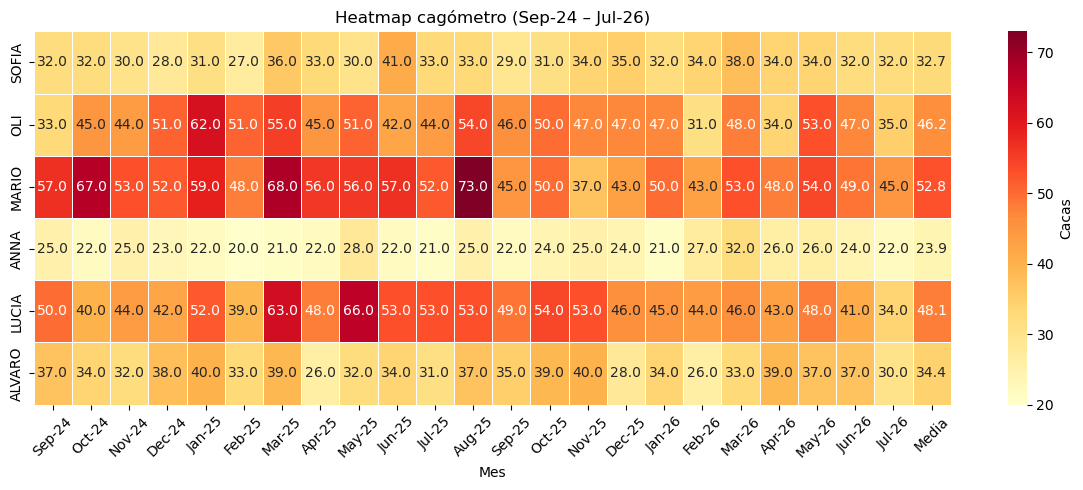

In [9]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 5))

sns.heatmap(df[cols_meses], annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Cacas"})

ax.set_title(f"Heatmap cagómetro ({primer_mes} – {ultimo_mes})")
ax.set_xlabel("Mes")
ax.set_ylabel("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

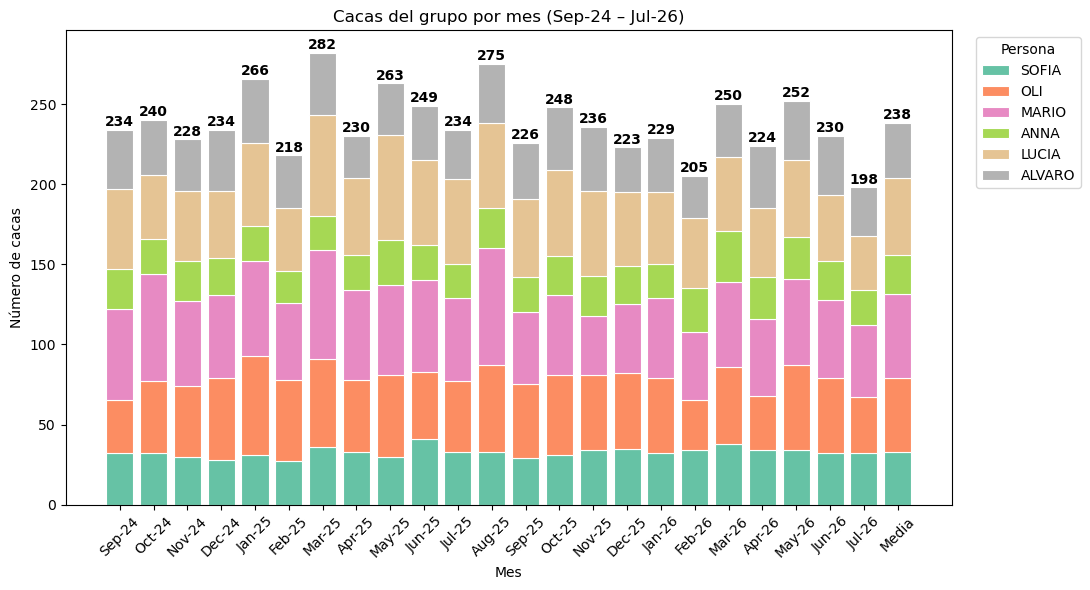

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Columnas que corresponden a meses
cols_meses = [c for c in df.columns if c != "Desviacion"]

fig, ax = plt.subplots(figsize=(11, 6))

bottom = np.zeros(len(cols_meses))

# Un color por persona (opcional)
colors = plt.cm.Set2(np.linspace(0, 1, len(df.index)))

for color, persona in zip(colors, df.index):

    valores = df.loc[persona, cols_meses].astype(float).values

    ax.bar(
        cols_meses,
        valores,
        bottom=bottom,
        label=persona,
        color=color,
        edgecolor="white",
        linewidth=0.8
    )

    bottom += valores

# Escribir el total encima de cada barra
for i, total in enumerate(bottom):
    ax.text(
        i,
        total + 0.5,
        f"{int(total)}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_xlabel("Mes")
ax.set_ylabel("Número de cacas")
ax.set_title(f"Cacas del grupo por mes ({primer_mes} – {ultimo_mes})")

ax.legend(title="Persona", bbox_to_anchor=(1.02, 1), loc="upper left")


#ax.spines["top"].set_visible(False)
#ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.25)
ax.grid(False)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()